<a href="https://colab.research.google.com/github/sondebisola/GroupA--MAITM6341SP25Midterm/blob/main/DEMO_ANN_on_MNIST_Handwriting_Sigmoid_LONG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Import necessary libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import time  # Import the time module

In [ ]:
DIGIT_TO_CLASSIFY = 5
EPOCHS = 40
PATIENCE = 5
RANDOM_SEED = 23
BATCH_SIZE = 32
MODEL_PATH = f"best_mnist_digit_{DIGIT_TO_CLASSIFY}_model.keras"

## Prepare the data

In [ ]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
print("TRAINNG DATA")
# Can see that in x data we have 60,000 28x28 pixel images
print(x_train.shape)
# Can see that we have one label for each of the 60,000 images
print(y_train.shape)

print("\nTESTING DATA")
# Can see that in x data we have 10,000 28x28 pixel images
print(x_test.shape)
# Can see that we have one label for each of the 10,000 images
print(y_test.shape)

print('\n Testing to Training ratio =', x_test.shape[0]/x_train.shape[0])

TRAINNG DATA
(60000, 28, 28)
(60000,)

TESTING DATA
(10000, 28, 28)
(10000,)

 Testing to Training ratio = 0.16666666666666666


In [ ]:
# Can see each element in x data is 28x28 array where each value is the grayscale value of the pixel from 0-255 where black(255)/white(0)
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

In [ ]:
# Normalize the x data to [0, 1]
x_train = x_train / 255.0
x_test = x_test / 255.0

In [ ]:
# Can see that we successfully normalized x data
x_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [ ]:
# Can see that the target value is the correct digit 0-9
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [ ]:
# Count the number of occurrences of each class in y_train and y_test
train_class_counts = np.bincount(y_train)
test_class_counts = np.bincount(y_test)

# Print the counts for the training data
print("Class counts in the training data:")
for i in range(len(train_class_counts)):
    print(f"Digit {i}: {train_class_counts[i]} samples")

# Print the counts for the test data
print("\nClass counts in the test data:")
for i in range(len(test_class_counts)):
    print(f"Digit {i}: {test_class_counts[i]} samples")

Class counts in the training data:
Digit 0: 5923 samples
Digit 1: 6742 samples
Digit 2: 5958 samples
Digit 3: 6131 samples
Digit 4: 5842 samples
Digit 5: 5421 samples
Digit 6: 5918 samples
Digit 7: 6265 samples
Digit 8: 5851 samples
Digit 9: 5949 samples

Class counts in the test data:
Digit 0: 980 samples
Digit 1: 1135 samples
Digit 2: 1032 samples
Digit 3: 1010 samples
Digit 4: 982 samples
Digit 5: 892 samples
Digit 6: 958 samples
Digit 7: 1028 samples
Digit 8: 974 samples
Digit 9: 1009 samples


In [ ]:
# Currently, y-label is the correct digit 0-9

# Convert targets to binary classification (1 if digit equals DIGIT_TO_CLASSIFY, 0 otherwise)
y_train = (y_train == DIGIT_TO_CLASSIFY).astype(int)
y_test = (y_test == DIGIT_TO_CLASSIFY).astype(int)

# Can see that we successfully changed the target labels to 0's and 1's
y_train

array([1, 0, 0, ..., 1, 0, 0])

In [ ]:
# Split the training data into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.1666666, random_state=RANDOM_SEED)


In [ ]:
print("TRAINNG DATA")
# Can see that in x data we have 60,000 28x28 pixel images
print(x_train.shape)

print("\nVALIDATION DATA")
# Can see that in x data we have 60,000 28x28 pixel images
print(x_val.shape)

print("\nTEST DATA")
# Can see that in x data we have 60,000 28x28 pixel images
print(x_test.shape)

print('\n Validation to Training ratio =', x_val.shape[0]/x_train.shape[0])
print('\n Testing to Training ratio =', x_test.shape[0]/x_train.shape[0])

TRAINNG DATA
(50000, 28, 28)

VALIDATION DATA
(10000, 28, 28)

TEST DATA
(10000, 28, 28)

 Validation to Training ratio = 0.2

 Testing to Training ratio = 0.2


## Build and Train the Model

In [ ]:
# Build the neural network
model = keras.Sequential([
    keras.layers.Input(shape=(28, 28)),  # Input layer
    keras.layers.Flatten(),  # Flatten the 28x28 input images
    keras.layers.Dense(units=25, activation='relu'),   # Fully connected layer
    keras.layers.Dense(units=15, activation='relu'),    # Additional hidden layer
    keras.layers.Dense(units=1, activation='sigmoid')  # Output layer
])

# Compile the model
model.compile(optimizer='adam',
              loss= 'binary_crossentropy',  # Use binary crossentropy for sigmoid
              metrics=['accuracy'])  # Use accuracy as a metric for integer labels

In [ ]:
# total number of parameters in model
total_params = model.count_params()
print(f"Total number of parameters: {total_params}")

# total number of trainable parameters in model
trainable_params = np.sum([np.prod(v.shape) for v in model.trainable_variables])
print(f"Number of trainable parameters: {trainable_params}")

Total number of parameters: 20031
Number of trainable parameters: 20031


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │        19,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,031 (78.25 KB)

 Trainable params: 20,031 (78.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# from tensorflow.keras.utils import plot_model

# # Plot the model
# plot_model(model, to_file='ANN_model.png', show_shapes=True, show_layer_names=True)

In [ ]:
# Train the Neural Network

# --- Implement Early Stopping ---
# Define the EarlyStopping callback
# This will monitor the validation loss and stop training if it doesn't improve
# for PATIENCE consecutive epochs. It will also restore the best weights found.
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',  # Metric to monitor
    patience=PATIENCE,          # Number of epochs to wait for improvement
    verbose=1,           # Print a message when stopping
    restore_best_weights=True  # Restore model weights from the epoch with the best value
)

# Start the timer
start_time = time.time()

# Train the model
history = model.fit(x_train,
                    y_train,
                    validation_data=(x_val, y_val), # Here I explicitly used the validation data made earlier
                    epochs=EPOCHS,
                    callbacks=[early_stopping], # Add the early stopping callback here
                    batch_size=BATCH_SIZE,
                    )

# Stop the timer
end_time = time.time()
# Calculate training time
training_time = end_time - start_time
# Print the training time
print("Training Time: {:.2f} seconds".format(training_time))

Epoch 1/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9525 - loss: 0.1378 - val_accuracy: 0.9906 - val_loss: 0.0306
Epoch 2/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9913 - loss: 0.0300 - val_accuracy: 0.9932 - val_loss: 0.0237
Epoch 3/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9933 - loss: 0.0209 - val_accuracy: 0.9918 - val_loss: 0.0238
Epoch 4/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9946 - loss: 0.0168 - val_accuracy: 0.9908 - val_loss: 0.0275
Epoch 5/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9956 - loss: 0.0132 - val_accuracy: 0.9930 - val_loss: 0.0211
Epoch 6/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9969 - loss: 0.0095 - val_accuracy: 0.9932 - val_loss: 0.0222
Epoch 7/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9971 - loss: 0.0085 - val_accuracy: 0.9943 - val_loss: 0.0202
Epoch 8/40
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9981 - loss: 0.0064 -

In [ ]:
# Saving the model
model.save(MODEL_PATH)
print(f"Best model saved to: {MODEL_PATH}")

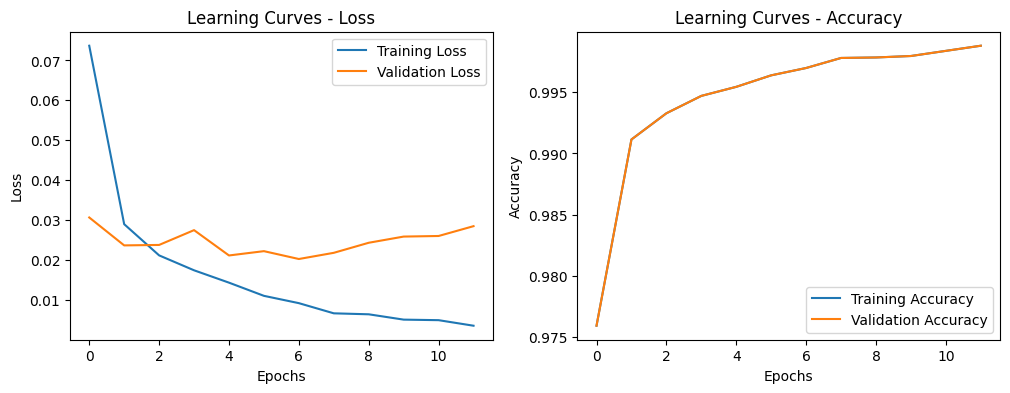

In [ ]:
# Plot learning curves
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Learning Curves - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['accuracy'], label='Validation Accuracy')
plt.title('Learning Curves - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

##Evaluation

In [ ]:
# Evaluate the model on the test set
print("\n--- Evaluating Model ---")
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")


--- Evaluating Model ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9922 - loss: 0.0210
Test Accuracy: 0.9938
Test Loss: 0.0177


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

       Not 5       1.00      1.00      1.00      9108
        Is 5       0.95      0.98      0.97       892

    accuracy                           0.99     10000
   macro avg       0.98      0.99      0.98     10000
weighted avg       0.99      0.99      0.99     10000



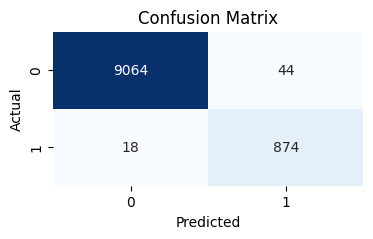

In [ ]:
# Have model make predictions on test data
y_pred_prob = model.predict(x_test)

# Convert probabilities to binary class labels (0 or 1)
y_pred = (y_pred_prob > 0.5).astype("int32")
# print(y_pred)  # Can see that probabilities have been mapped to 0 and 1

# Print the classification report
print(classification_report(y_test, y_pred, target_names=[f'Not {DIGIT_TO_CLASSIFY}', f'Is {DIGIT_TO_CLASSIFY}']))

# Make confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(4, 2))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=range(2), yticklabels=range(2))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

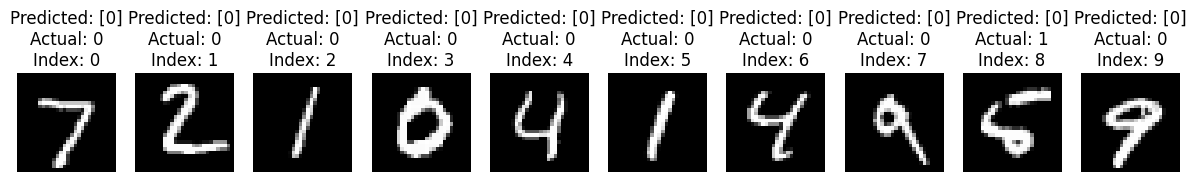

In [ ]:
# Display some test images and their predicted labels
num_samples = 10
plt.figure(figsize=(15, 5))
for i in range(num_samples):
    plt.subplot(1, num_samples, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.title(f"Predicted: {y_pred[i]}\nActual: {y_test[i]}\nIndex: {i}")
    plt.axis('off')
plt.show()
